In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [3]:
df = pd.read_csv("cardio_train.csv",sep=";")

In [4]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df.drop("id",axis=1,inplace=True)

In [6]:
df['age']=df['age']//365

In [7]:
df['gender'] = df['gender'].map({1:0,2:1})

In [8]:
df.tail()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,52,1,168,76.0,120,80,1,1,1,0,1,0
69996,61,0,158,126.0,140,90,2,2,0,0,1,1
69997,52,1,183,105.0,180,90,3,1,0,1,0,1
69998,61,0,163,72.0,135,80,1,2,0,0,0,1
69999,56,0,170,72.0,120,80,2,1,0,0,1,0


In [9]:
df["cholesterol"] = df["cholesterol"].map({1:0, 2:1, 3:2})
df["gluc"] = df["gluc"].map({1:0, 2:1, 3:2})

In [10]:
df = pd.get_dummies(df, columns=["alco","active"], drop_first=True)#nominal data 
#one hot encoding

In [15]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,cardio,alco_1,active_1
0,50,1,168,62.0,110,80,0,0,0,0,False,True
1,55,0,156,85.0,140,90,2,0,0,1,False,True
2,51,0,165,64.0,130,70,2,0,0,1,False,False
3,48,1,169,82.0,150,100,0,0,0,1,False,True
4,47,0,156,56.0,100,60,0,0,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,1,168,76.0,120,80,0,0,1,0,False,True
69996,61,0,158,126.0,140,90,1,1,0,1,False,True
69997,52,1,183,105.0,180,90,2,0,0,1,True,False
69998,61,0,163,72.0,135,80,0,1,0,1,False,False


# handling outliers

In [12]:
df = df[df['height']<250]

In [14]:
df = df[(df['weight'] > 30) & (df['weight'] < 200)]


In [16]:
# Clean systolic BP (ap_hi)
df = df[(df['ap_hi'] >= 70) & (df['ap_hi'] <= 250)]

# Clean diastolic BP (ap_lo)
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 150)]


In [ ]:
scaler = StandardScaler()  #StandardScaler() is used to standardize features by removing the mean and scaling to unit variance. It transforms the data such that the distribution has a mean value 0 and standard deviation of 1.
num_cols = ["age","height","weight","ap_hi","ap_lo"]
df[num_cols] = scaler.fit_transform(df[num_cols])  # in this line, the StandardScaler is applied to the specified numerical columns in the DataFrame. The fit_transform method computes the mean and standard deviation for each column and then scales the data accordingly. This ensures that the numerical features are standardized, which can improve the performance of machine learning algorithms that are sensitive to the scale of input features.

In [17]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,cardio,alco_1,active_1
0,50,1,168,62.0,110,80,0,0,0,0,False,True
1,55,0,156,85.0,140,90,2,0,0,1,False,True
2,51,0,165,64.0,130,70,2,0,0,1,False,False
3,48,1,169,82.0,150,100,0,0,0,1,False,True
4,47,0,156,56.0,100,60,0,0,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,1,168,76.0,120,80,0,0,1,0,False,True
69996,61,0,158,126.0,140,90,1,1,0,1,False,True
69997,52,1,183,105.0,180,90,2,0,0,1,True,False
69998,61,0,163,72.0,135,80,0,1,0,1,False,False


In [19]:
X = df.drop(columns='cardio')
Y = df['cardio']

In [20]:
X

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco_1,active_1
0,-0.417885,1,0.445110,-0.847497,-0.992232,-0.142029,0,0,0,False,True
1,0.320799,0,-1.022802,0.760261,0.799350,0.904565,2,0,0,False,True
2,-0.270148,0,0.078132,-0.707692,0.202156,-1.188623,2,0,0,False,False
3,-0.713359,1,0.567436,0.550554,1.396544,1.951159,0,0,0,False,True
4,-0.861095,0,-1.022802,-1.266912,-1.589426,-2.235217,0,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...
69995,-0.122411,1,0.445110,0.131139,-0.395038,-0.142029,0,0,1,False,True
69996,1.207220,0,-0.778150,3.626265,0.799350,0.904565,1,1,0,False,True
69997,-0.122411,1,2.280000,2.158312,3.188126,0.904565,2,0,0,True,False
69998,1.207220,0,-0.166520,-0.148471,0.500753,-0.142029,0,1,0,False,False


In [21]:
Y

0        0
1        1
2        1
3        1
4        0
        ..
69995    0
69996    1
69997    1
69998    1
69999    0
Name: cardio, Length: 68742, dtype: int64

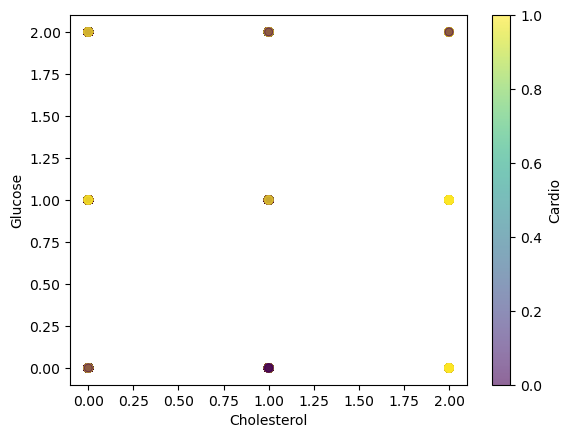

In [22]:
import matplotlib.pyplot as plt

plt.scatter(df['cholesterol'],df['gluc'],c=df['cardio'],alpha=.6)
plt.xlabel("Cholesterol")
plt.ylabel("Glucose")
plt.colorbar(label="Cardio")
plt.show()

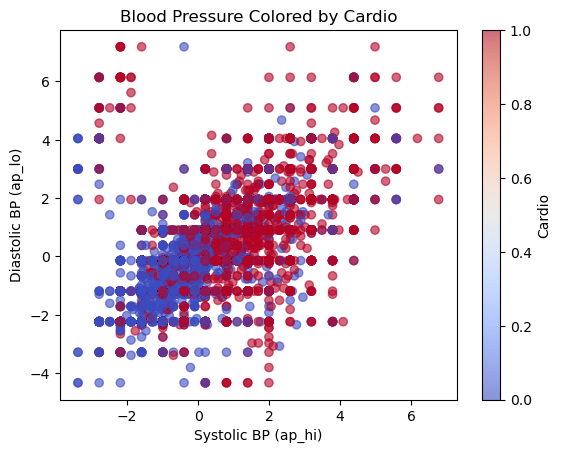

In [23]:
plt.scatter(df['ap_hi'], df['ap_lo'], c=df['cardio'], cmap='coolwarm', alpha=0.6)
plt.xlabel("Systolic BP (ap_hi)")
plt.ylabel("Diastolic BP (ap_lo)")
plt.title("Blood Pressure Colored by Cardio")
plt.colorbar(label="Cardio")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2)

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
clf = LogisticRegression()

In [27]:
clf.fit(X_train,Y_train)

LogisticRegression()

In [28]:
y_pred = clf.predict(X_test)

In [29]:
y_pred

array([1, 0, 1, ..., 1, 1, 0], dtype=int64)

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy_score(Y_test,y_pred)

0.7308167866753946